# ASDEA_sensors -- complete showcase (v2)

Everything the package can do, on one window, written to be followed step by
step. v2 adds the **all-sensor** views: Newmark, RotD, PSD, Fourier and the
ambient mean spectrum are shown for every device at once (`group=True`), on top
of the single-sensor deep dive.

Conventions:
* tunable values are plain variables with a leading underscore (`_time_start`,
  `_device`, `_fmin`, ...);
* every function is called with its inputs one per line;
* `save=...` is left commented so nothing is written to disk;
* no hidden loops -- single-sensor work uses the chain, multi-sensor work uses
  the list helpers (`..._all`, which take the device list directly).

## 0. Imports

In [1]:
%matplotlib inline

import numpy as np
from datetime import datetime

from asdea_sensors import SensorDataset
from asdea_sensors.config import settings

## 1. Read the data (only read)

In [2]:
_folder = r"C:\Users\ppala\Desktop\02_31MAY2026"

ds = SensorDataset(_folder, verbose=True)
print("devices    :", ds.devices)
print("max points :", format(ds.max_points, ","))

------------------------------------------------------------
SensorDataset
------------------------------------------------------------
path        : C:\Users\ppala\Desktop\02_31MAY2026
files       : 32
time span   : 2026-05-31 14:52:12  ->  2026-05-31 20:02:13
duration    : 18601.0 s
devices     : MNAT0031, MNAT0034, MOF00134, MOF00135, MOF00136
fs / dt     : 252.5885 Hz / 0.003959 s
max points  : 4,836,520 samples/axis (largest device)
------------------------------------------------------------
axes (per sensor):
  MNAT0031   -> (3, 1, 5)
  MNAT0034   -> (3, 1, 5)
  MOF00134   -> (0, 1, 2)
  MOF00135   -> (3, 1, 5)
  MOF00136   -> (3, 1, 5)
------------------------------------------------------------
on-disk size: 782.17 MB
RAM         : used 14.06 GB / avail 19.45 GB (42%)
------------------------------------------------------------
devices    : ['MNAT0031', 'MNAT0034', 'MOF00134', 'MOF00135', 'MOF00136']
max points : 4,836,520


## 2. Resample to a uniform dt (before any treatment)

In [3]:
_dt = 0.004                 # target sampling interval [s]  (fs = 250 Hz)
_fs = round(1.0 / _dt)

ds = ds.resample(dt=_dt)
print("uniform dt =", _dt, "s   ->   fs =", _fs, "Hz")

uniform dt = 0.004 s   ->   fs = 250 Hz


## 3. Overview of every sensor + the window to analyse

In [ ]:
from asdea_sensors.plotting import overview_plots

_time_start = datetime(2026, 5, 31, 17, 35, 0)
_time_end   = datetime(2026, 5, 31, 17, 45, 0)

_devices = ["MOF00134", "MNAT0031", "MNAT0034", "MOF00135", "MOF00136"]

_titles = {
    "MOF00134": "Subterraneo",
    "MNAT0031": "Primer Piso",
    "MNAT0034": "Entrada Edificio",
    "MOF00135": "Salida Facultad",
    "MOF00136": "Sala Reuniones Facultad",
}
ds.titles = _titles          # devices/titles/colors live on the object now

overview_plots.plot_overview(
    ds,
    factor  = 1.0,
    unit    = "g",
    window  = (_time_start, _time_end),
    figsize = (17, 7),
    # save  = "overview.pdf",
)

## 4. Filter band used for every treatment below (input)

In [ ]:
_fmin, _fmax = 0.2, 20.0     # band-pass edges [Hz]
_zeta = 0.05                 # damping for the spectra

# Condition the object once; the plots below only draw it.
_wb = ds.get_window(_time_start, _time_end).baseline()                 # baseline only
_wf = _wb.filter(_fmin, _fmax, engine="scipy")                         # + band-pass

## 5. Accelerogram of all sensors (overlaid, in g)

`group=True` overlays the five sensors per component; `baseline=True` removes
the DC offset so the overlay is comparable.

In [ ]:
from asdea_sensors.plotting import signal_plots

signal_plots.plot_signals_all(
    _wb,
    components = "all",
    kind       = "acc",
    factor     = 1/9.81,
    unit       = "g",
    time_axis  = "relative",
    group      = True,
    figsize    = (13, 7),
)

## 6. Fourier of all sensors (filtered, overlaid per component)

In [ ]:
from asdea_sensors.plotting import fourier_plots

_spectra = _wf.fourier(component="all", num_frequencies=4, smooth="konno", bexp=40)

fourier_plots.plot_fourier_all(
    _wf, _spectra,
    components = ("x", "y", "z"),
    layout     = "overlay",
    figsize    = (12, 8),
    xlim       = (0, 25),
)

## 7. Fourier filtered vs unfiltered (one figure per sensor)

In [ ]:
_pair = {d: _spectra[d] for d in ["MOF00135", "MOF00134"]}

fourier_plots.plot_fourier_all(
    _wf, _pair,
    components = ("x",),
    layout     = "grid",
    figsize    = (10, 3.5),
    xlim       = (0, 25),
)

## 8. Newmark response spectra of all sensors (PSa in g, overlaid)

In [ ]:
from asdea_sensors.plotting import newmark_plots

_specs = _wf.newmark(component="x", zeta=_zeta, max_period=3.0, dT=0.02, factor=1/9.81)

newmark_plots.plot_newmark_all(
    _wf, _specs,
    component = "x",
    quantity  = "PSa",
    unit      = "g",
    layout    = "overlay",
    figsize   = (10, 5),
    xlim      = (0, 3),
)

## 9. RotD50 of all sensors (overlaid)

In [ ]:
from asdea_sensors.plotting import rotd_plots

_rotds = _wf.rotd(comp_x="x", comp_y="y", rotd=[0, 50, 100], damping=_zeta,
                 angle_step=15, max_period=3.0, dT=0.02)

rotd_plots.plot_rotd_all(
    _wf, _rotds,
    rotd    = [0, 50, 100],
    figsize = (10, 5),
    xlim    = (0, 3),
)

## 10. PSD of all sensors + band energy across sensors

In [ ]:
from asdea_sensors.plotting import psd_plots

_psds = _wf.psd(component="x", nperseg=512, noverlap=256, window="hann",
               bands=[(0, 1), (1, 2.5), (2.5, 5), (5, 10)])

psd_plots.plot_psd_all(
    _wf, _psds,
    component = "x",
    layout    = "overlay",
    figsize   = (10, 5),
    xlim      = (0, 25),
)

# Band energy compared across sensors (1-2.5 Hz band).
psd_plots.plot_psd_bands(_psds, band=(1, 2.5), figsize=(8, 4))

## 11. Predominant frequency of all sensors (ambient mean spectra)

In [ ]:
from asdea_sensors.plotting import ambient_plots

_amb_all = _wb.ambient(
    sta=1.0, lta=30.0, vent=30.0, vmin=0.7, vmax=1.4, p=0.05, bexp=80,
    component="x", kind="acc",
)

_f0 = ambient_plots.plot_mean_spectrum_all(
    _wb, _amb_all,
    component = "x",
    layout    = "overlay",
    figsize   = (11, 5),
    xlim      = (0, 25),
)
print("f0 per sensor [Hz]:", {d: round(v, 2) for d, v in _f0.items()})

# config kept for the HVSR cell below (hvsr.compute still takes a config dict).
_config = {"Fs": _fs, "STA": 1, "LTA": 30, "vent": 30,
           "vmin": 0.7, "vmax": 1.4, "p": 0.05, "bexp": 80, "f1": 0.2, "f2": 20.0}

## 12. One sensor in detail (the chain) + accelerogram in g

[signal] MNAT0034 n=150001 dt=0.004000 comps=all
MNAT0034 : 150001 samples, 600.0 s, dt=0.004000 s
from 2026-05-31T17:35:00.000000000 to 2026-05-31T17:45:00.000000000


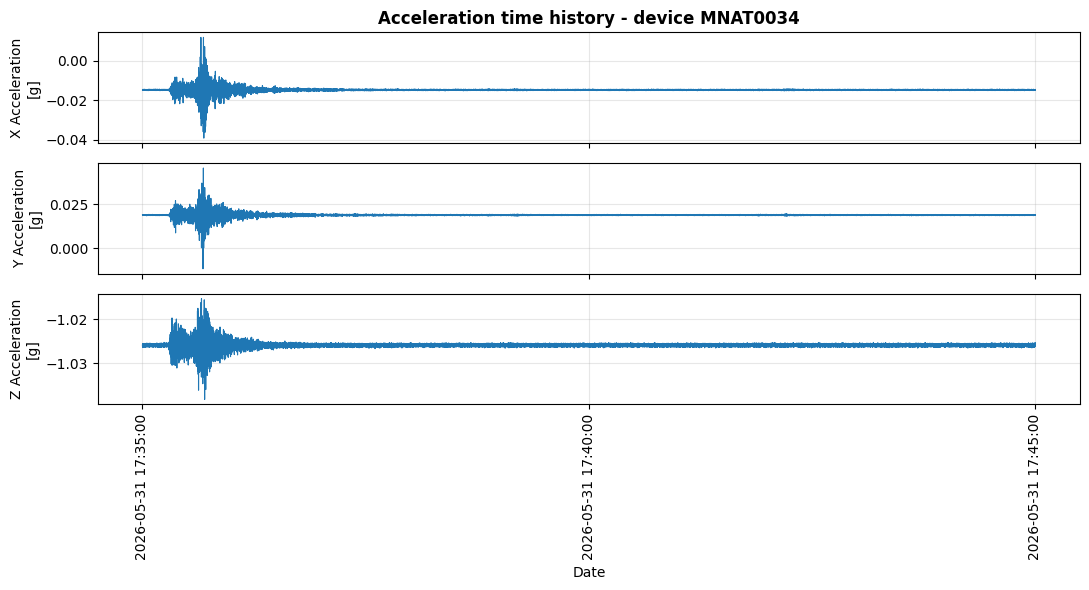

In [13]:
_device = "MNAT0034"

_sig = ds.device(_device).get_window(_time_start, _time_end).signal(components="all")
print("%s : %d samples, %.1f s, dt=%.6f s" % (_device, _sig.n, _sig.duration, _sig.dt))
print("from %s to %s" % (_sig.t_abs[0], _sig.t_abs[-1]))

signal_plots.plot_signals(
    _sig,
    components="all",
    kind="acc",
    factor=1/9.81,
    unit="g",
    time_axis="absolute",
    figsize=(11, 6),
    xlim=None,
    ylim=None,
    # save="acc_one.pdf",
)

## 13. Corrections + band-pass for that sensor (acc/vel/disp)

[signal] MNAT0034 n=150001 dt=0.004000 comps=all


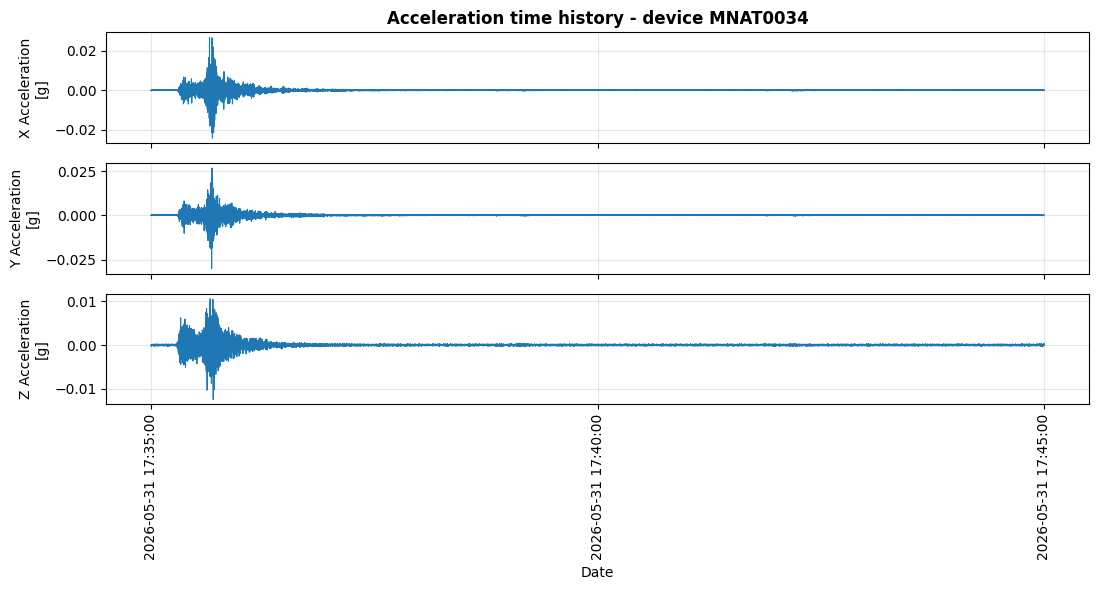

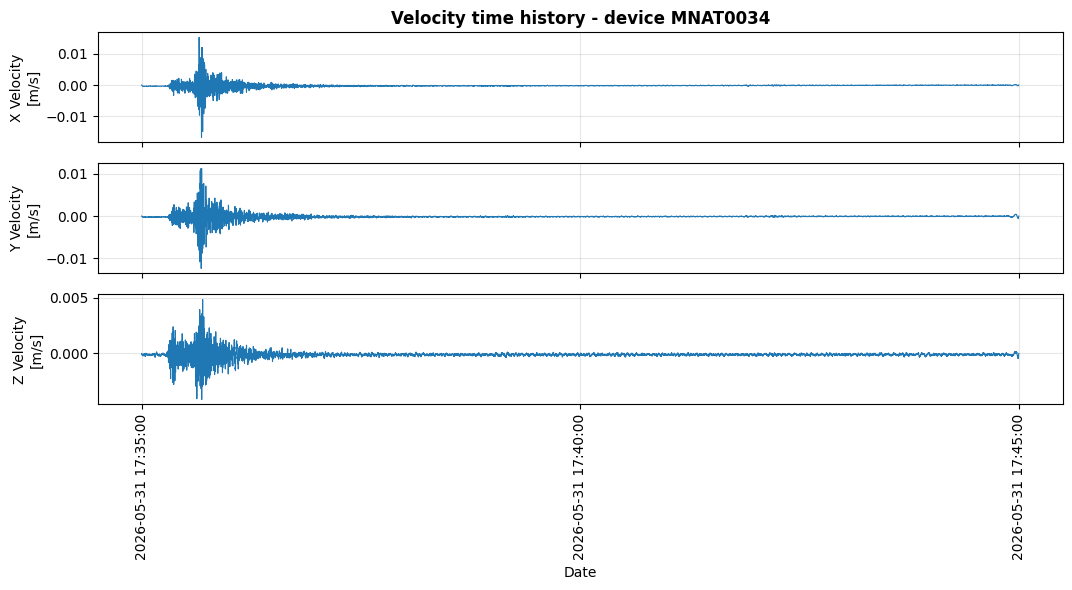

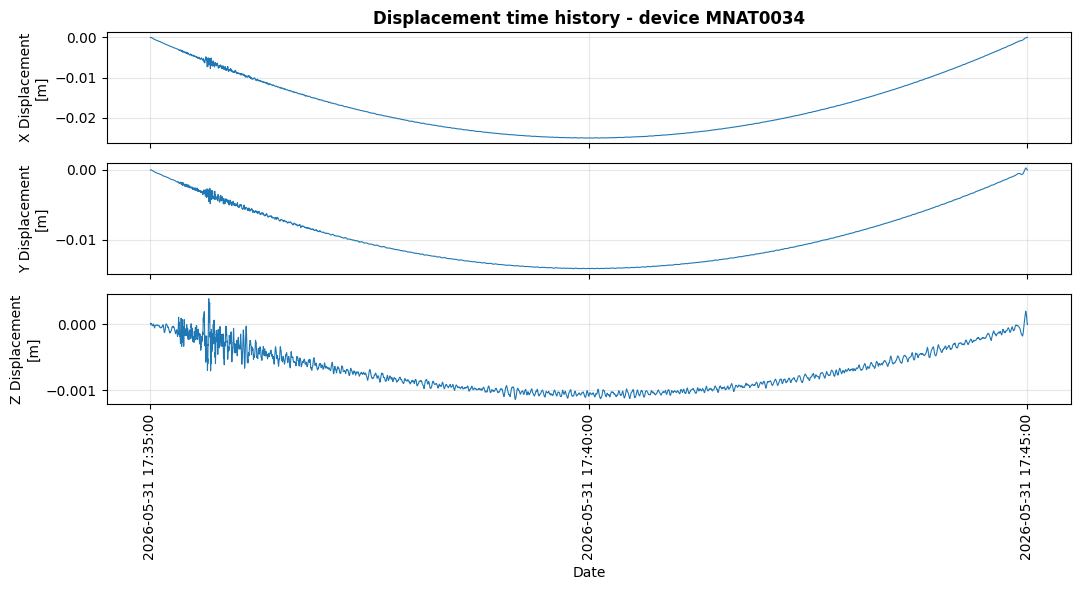

In [14]:
_proc = (ds.device(_device).get_window(_time_start, _time_end)
           .baseline()
           .filter(_fmin, _fmax, engine="scipy")
           .derive())
_sig_p = _proc.signal(components="all")

signal_plots.plot_signals(_sig_p, components="all", kind="acc",  factor=1/9.81, unit="g", figsize=(11, 6))
signal_plots.plot_signals(_sig_p, components="all", kind="vel",  figsize=(11, 6))
signal_plots.plot_signals(_sig_p, components="all", kind="disp", figsize=(11, 6))

## 14. Intensity measures for that sensor (Arias, CAV, Housner, peaks)

[arias] MNAT0034 comp=x low=5 high=95 (computed)


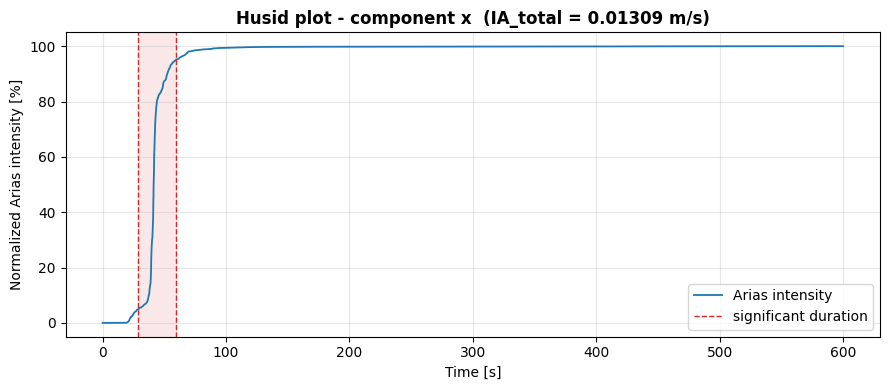

[cav] MNAT0034 comp=x (computed)
CAV    = 1.74864


[housner] MNAT0034 comp=x T1=0.1 T2=2.5 (computed)
SI     = 0.051386
[peaks] MNAT0034 comp=x PGA=0.2615 (computed)
[peaks] MNAT0034 comp=y PGA=0.2966 (computed)
[peaks] MNAT0034 comp=z PGA=0.1222 (computed)
peaks  = {'PGA': 0.26147, 'PGV': 0.01679, 'PGD': 0.0251}


In [15]:
from asdea_sensors.plotting import arias_plots

_wfd = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").derive()

_arias = dict(_wfd.arias(component="x", low=5, high=95)); _arias["dt"] = _dt
arias_plots.plot_arias(_arias, component="x", figsize=(9, 4))

print("CAV    =", round(float(_wfd.cav(component="x")["CAV"]), 5))
print("SI     =", round(float(_wfd.housner(component="x", T1=0.1, T2=2.5, zeta=_zeta)["SI"]), 6))
print("peaks  =", {k: round(float(v), 5) for k, v in _wfd.peaks(component="all")["x"].items()})

## 15. STFT spectrogram for that sensor

[stft] MNAT0034 comp=x nperseg=256 fmax=25.0 (computed)


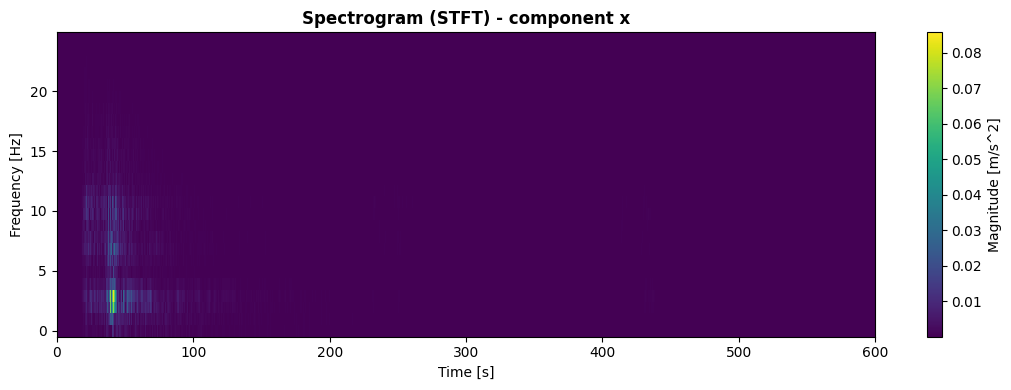

In [16]:
from asdea_sensors.plotting import stft_plots

_wf = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy")
_stft = _wf.stft(component="x", nperseg=256, noverlap=224, window="hann", fmax=25.0)
stft_plots.plot_stft(_stft, component="x", figsize=(11, 4))

## 16. Ambient analysis, step by step (see every algorithm)

STA/LTA, window selection, taper, FFT, Konno-Ohmachi and the mean spectrum,
each one visible -- like the old `BuildPeriod` with `display_figures=True`.

In [ ]:
_amb = ds.device(_device).get_window(_time_start, _time_end).baseline().ambient(
    sta=1.0, lta=30.0, vent=30.0, vmin=0.7, vmax=1.4, p=0.05, bexp=80, component="x",
)

In [ ]:
# STA/LTA, windows and spectrum for that sensor (one result -> detail plots).
ambient_plots.plot_sta_lta(_amb, figsize=(11, 6))

In [ ]:
ambient_plots.plot_windows_all(ds, _amb, figsize=(11, 4))

In [ ]:
ambient_plots.plot_spectrum(_amb, peak_spacing_hz=0.2, num_peaks=4, min_freq=0.3)

## 17. HVSR (Nakamura) for that sensor

[signal] MNAT0034 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 17 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed
- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3797 s)
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 15 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3896 s)
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 17 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed
- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.1402 s)


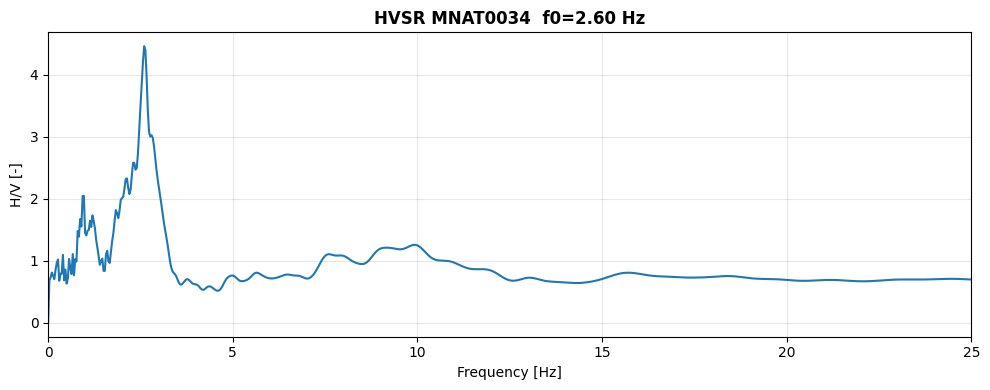

In [21]:
from asdea_sensors.ambient import hvsr
import matplotlib.pyplot as plt

_s = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="all")
_hv = hvsr.compute(_s.acc_x, _s.acc_y, _s.acc_z, _config, combine="geometric")

plt.figure(figsize=(10, 4))
plt.plot(_hv["freqs"], _hv["HV"])
plt.xlim(0, 25)
plt.xlabel("Frequency [Hz]"); plt.ylabel("H/V [-]")
plt.title("HVSR %s  f0=%.2f Hz" % (_device, _hv["f0"]), fontweight="bold")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 18. Correlation between sensors (building)

Transfer function floor/base (peaks = modal frequencies) and coherence
(trustworthy where ~1).

[signal] MOF00134 n=150001 dt=0.004000 comps=x


[signal] MOF00135 n=150001 dt=0.004000 comps=x


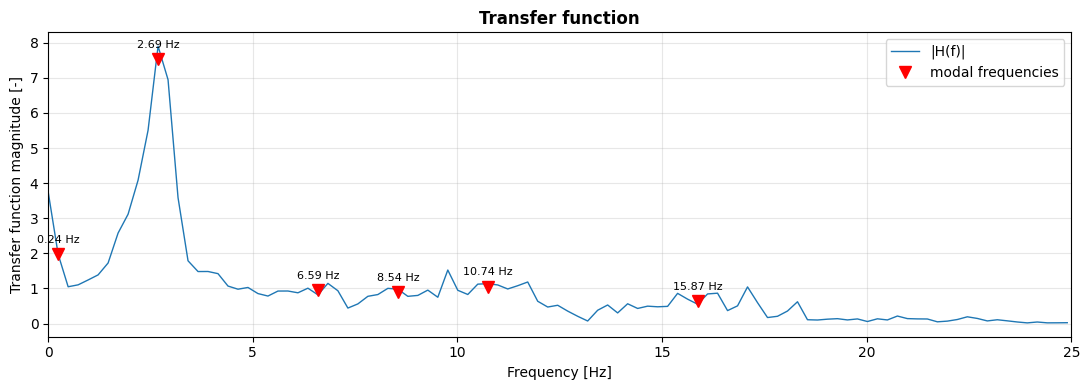

modal freqs (Hz): [0.24, 2.69, 6.59, 8.54, 10.74]


In [22]:
from asdea_sensors.building import transfer_function, coherence
from asdea_sensors.plotting import transfer_plots

_base = ds.device("MOF00134").get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="x").acc_x
_top  = ds.device("MOF00135").get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="x").acc_x
_n = min(len(_base), len(_top))

_frf = transfer_function.compute(
    _top[:_n], _base[:_n], _dt,
    estimator="H1",
    nperseg=1024,
    noverlap=512,
    smooth="konno",
    bexp=40,
    fmax=25.0,
)
transfer_plots.plot_transfer_function(_frf, figsize=(11, 4), xlim=(0, 25))
print("modal freqs (Hz):", [round(float(x), 2) for x in _frf["modal_freqs"][:5]])

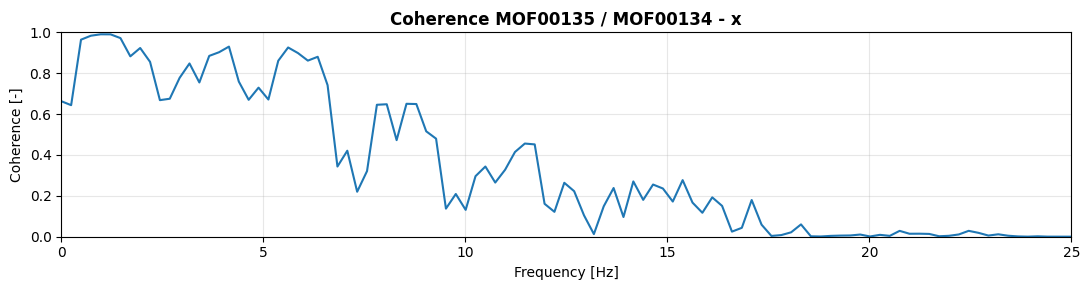

In [23]:
_coh = coherence.compute(_top[:_n], _base[:_n], _dt, nperseg=1024, noverlap=512)
plt.figure(figsize=(11, 3))
plt.plot(_coh["f"], _coh["coherence"])
plt.xlim(0, 25); plt.ylim(0, 1)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Coherence [-]")
plt.title("Coherence MOF00135 / MOF00134 - x", fontweight="bold")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 19. Export everything computed to a self-describing .h5 (commented)

In [24]:
# import tempfile, os
# _out = os.path.join(tempfile.gettempdir(), "%s_window.h5" % _device)
# _wfd.export_h5(_out)
# ds.export_h5("run_window.h5")
print("export shown commented so nothing is written to disk.")

export shown commented so nothing is written to disk.
